# Math 149: Topological and Algebraic Connectivity in Random Graphs

## setup

$Graph$ is an object that represents a graph. It is represented by $n$ nodes and a set of edges. It can also form its adjacency matrix and Laplacian matrix; compute the eigenvalues of the Laplacian and the Fiedler value (from sorted eigenvalues); compute its Euler characteristic; determine if it is connected via Breadth-First Search (BFS); and construct an Erdős-Rényi random graph given $n$ and $p$ (by including each possible edge from ${n}\choose{2}$ node pairs with probabilty $p$).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

In [ ]:
class Graph:
    """undirected graph class"""

    def __init__(self, n):
        ## graph representation
        self.n = n
        self.edges = set()
        self.adj = {i: [] for i in range(n)}

    def add_edge(self, i, j):
        if i == j:
            return
        if i > j:
            i, j = j, i
        if (i, j) not in self.edges:
            self.edges.add((i, j))
            self.adj[i].append(j)
            self.adj[j].append(i)

    def degree(self, v):
        ## get degree of a node (from adjecency list)
        return len(self.adj[v])

    def num_edges(self):
        ## |E|
        return len(self.edges)

    def is_connected(self):
        ## BFS (start from 0, BFS + track reached)
        if self.n <= 1:
            return True
        visited = {0}
        changed = True
        while changed:
            changed = False
            new_visited = set(visited)
            for v in visited:
                for neighbor in self.adj[v]:
                    if neighbor not in new_visited:
                        new_visited.add(neighbor)
                        changed = True
            visited = new_visited
        return len(visited) == self.n

    def adjacency_matrix(self):
        ## matrix representation (used for L)
        A = np.zeros((self.n, self.n))
        for i, j in self.edges:
            A[i, j] = 1
            A[j, i] = 1
        return A

    def laplacian_matrix(self):
        ## L = D - A
        A = self.adjacency_matrix()
        D = np.diag([self.degree(i) for i in range(self.n)])
        return D - A

    def fiedler_value(self):
        ## 2nd smallest of eigenvalues of L
        if self.n <= 1:
            return 0.0
        L = self.laplacian_matrix()
        eigenvalues = np.linalg.eigvalsh(L)
        return float(eigenvalues[1])

    def euler_characteristic(self):
        ## |V|-|E|
        return self.n - self.num_edges()

    def __repr__(self):
        return f"Graph(n={self.n}, edges={self.num_edges()})"


def erdos_renyi(n, p):
    """generate erdős-rényi random graph G(n, p)"""
    # add/include each possible edge/vertex-pair w p
    G = Graph(n)
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < p:
                G.add_edge(i, j)
    return G


In [ ]:
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 140,
    'font.size': 11,
    'font.family': 'serif',
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.facecolor': '#fafafa',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.5,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#cccccc',
    'legend.fontsize': 9,
})

PALETTE = ['#2176ae', '#e85d04', '#57a773', '#d62839']

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

---
## Experiment 1 — Connectivity of a Random Graph



For a fixed graph size ($n = 100$), how does connectivity depend on $p$? We sweep $p$ from 0 to 0.25 and compute:
- $P(\text{connected})$: fraction of $m=300$ trials in which $G(n,p)$ is connected.
- $E[\lambda_2]$: average Fiedler value (second-smallest eigenvalue of $L = D - A$).

For each $p$, we generate $m=300$ independent graphs and compute both statistics. $P(\text{connected})$ transitions from 0 to 1 near $p^* = \ln(100)/100 \approx 0.046$. $E[\lambda_2]$ takes off from 0 at the same point, since $\lambda_2 > 0$ if and only if $G$ is connected (Theorem 3.2).


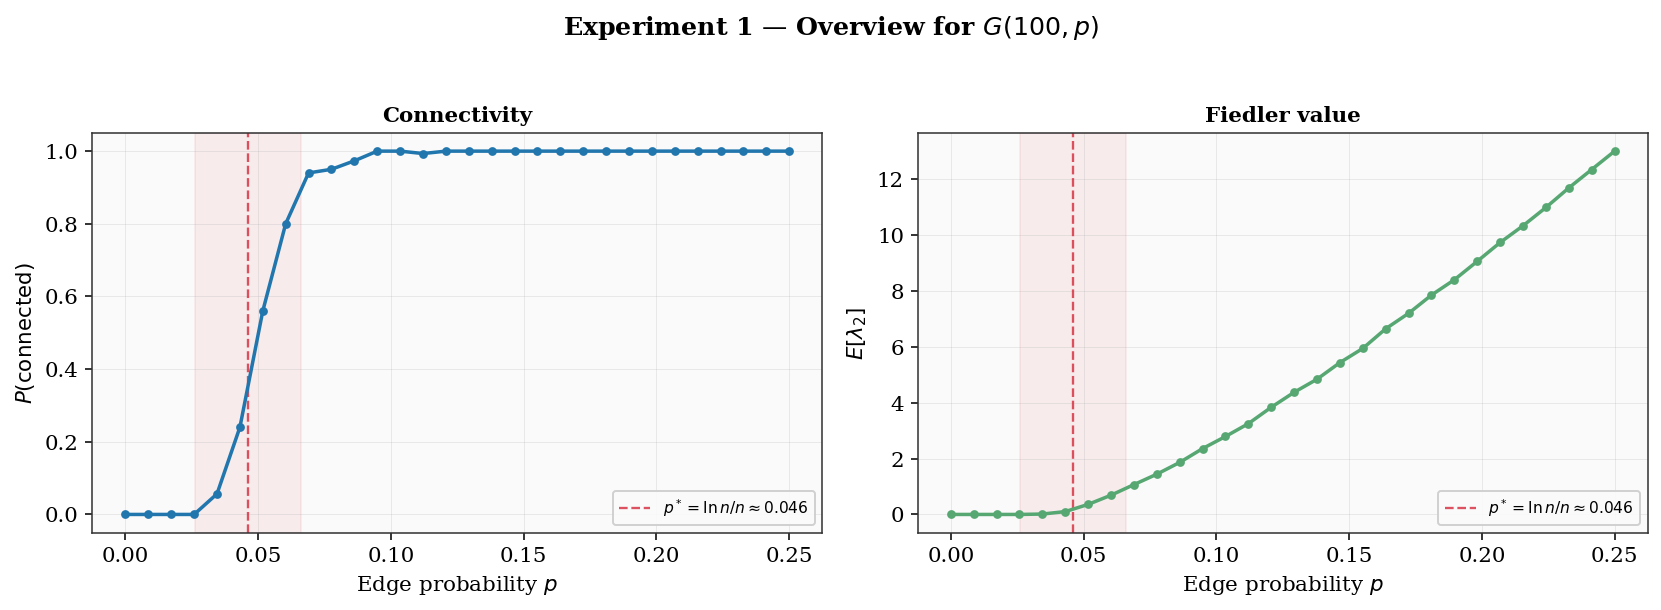

In [ ]:
n_overview = 100 # fixed size
trials_overview = 300 # m trials
p_grid_ov = np.linspace(0, 0.25, 30) # p sweep
p_star_ov = math.log(n_overview) / n_overview # theoretical critical threshold

prob_conn = []
avg_lam2_ov = []

for p in p_grid_ov:
    conn_count = 0
    lam2_sum = 0.0
    for _ in range(trials_overview):
        G = erdos_renyi(n_overview, p)
        if G.is_connected():
            conn_count += 1
        lam2_sum += G.fiedler_value()
    prob_conn.append(conn_count / trials_overview)
    avg_lam2_ov.append(lam2_sum / trials_overview)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

panel_colors = [PALETTE[0], PALETTE[2]]
panel_titles = ['Connectivity', 'Fiedler value']
panel_ylabels = ['$P(\\mathrm{connected})$', '$E[\\lambda_2]$']
panel_data = [prob_conn, avg_lam2_ov]

for idx, ax in enumerate(axes):
    ax.plot(p_grid_ov, panel_data[idx], color=panel_colors[idx],
            marker='o', markersize=3.5, linewidth=1.8, zorder=3)
    ax.axvline(p_star_ov, color=PALETTE[3], linestyle='--', linewidth=1.2,
               alpha=0.8, label=f'$p^* = \\ln n / n \\approx {p_star_ov:.3f}$', zorder=2)
    ax.axvspan(p_star_ov - 0.02, p_star_ov + 0.02, color=PALETTE[3], alpha=0.07, zorder=1)
    ax.set_xlabel('Edge probability $p$')
    ax.set_ylabel(panel_ylabels[idx])
    ax.set_title(panel_titles[idx], fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle(f'Experiment 1 — Overview for $G({n_overview}, p)$',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## Experiment 2 — Connectivity Threshold (Theorem 2.1)



Theorem 2.1 shows that $G(n,p)$ undergoes a phase transition at $p^* = \frac{\ln n}{n}$: below $p^*$ the graph is almost surely disconnected (isolated vertices persist), and above $p^*$ it is almost surely connected.

For each $n \in \{50,100,200,500\}$ we sweep $p$ over $[0, 0.25]$ and estimate $P(\text{connected})$ from $m=300$ independent samples of $G(n,p)$. We mark the theoretical threshold $p^* = \ln n / n$ as a dashed vertical line and observe the phase transitions across $n$.


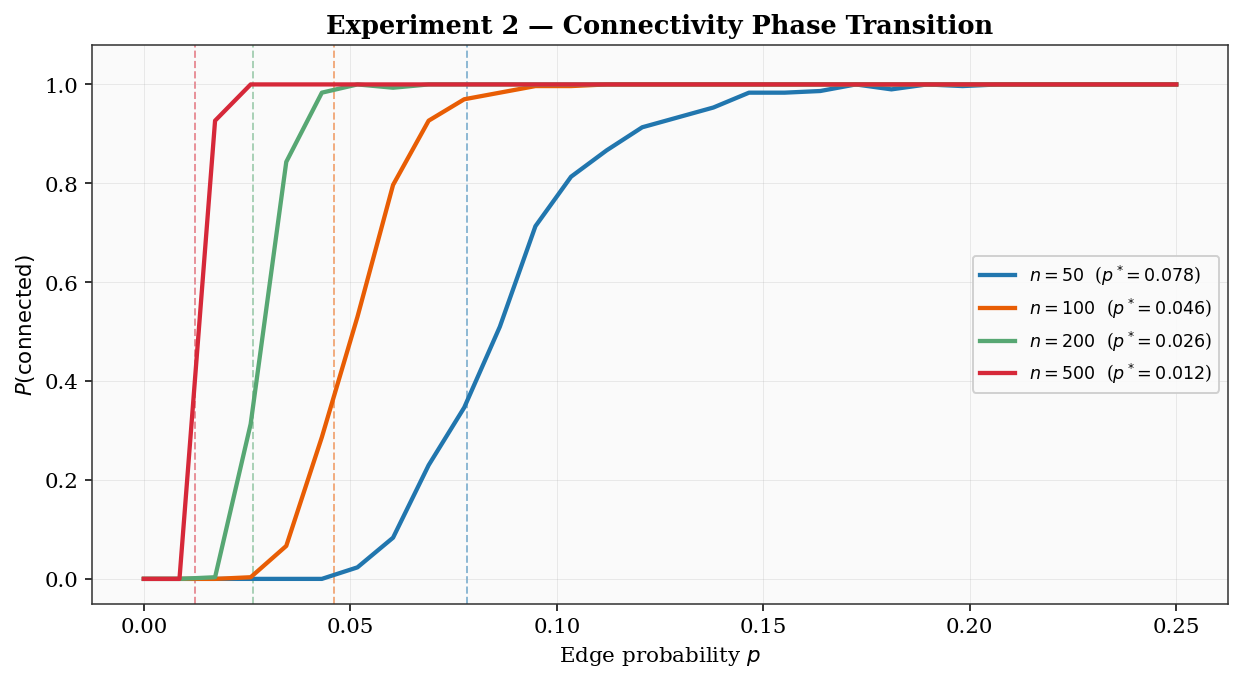

In [ ]:
n_values = [50, 100, 200, 500]
num_trials = 300
p_grid = np.linspace(0, 0.25, 30)

fig, ax = plt.subplots(figsize=(9, 5))

for idx, n in enumerate(n_values):
    probs = []
    for p in p_grid:
        conn = sum(1 for _ in range(num_trials) if erdos_renyi(n, p).is_connected())
        probs.append(conn / num_trials)

    p_star = math.log(n) / n
    c = PALETTE[idx]

    ax.plot(p_grid, probs, color=c, linewidth=2.2,
            label=f'$n={n}$  ($p^*\\!={p_star:.3f}$)', zorder=3)
    ax.axvline(p_star, color=c, linestyle='--', linewidth=1, alpha=0.5, zorder=1)

ax.set_xlabel('Edge probability $p$')
ax.set_ylabel('$P(\\mathrm{connected})$')
ax.set_title('Experiment 2 — Connectivity Phase Transition', fontweight='bold')
ax.legend(loc='center right')
ax.set_ylim(-0.05, 1.08)
plt.tight_layout()
plt.show()

---
## Experiment 3 — Fiedler Value Evolution (Theorem 3.2)



Theorem 3.2 shows that $\lambda_2 > 0$ if and only if $G$ is connected. So $E[\lambda_2]$ should be near zero when most graphs are disconnected and begin rising precisely at the connectivity threshold.

For $n \in \{50,100,200, 500\}$, sweep $p$ over $[0, 0.25]$. At each $(n,p)$, we generate $m=300$ graphs, compute $\lambda_2$ for each (the second-smallest eigenvalue of $L = D - A$), and average. We observe how $\lambda_2$ stays near 0 for $p < \ln n / n$, then rises roughly linearly.

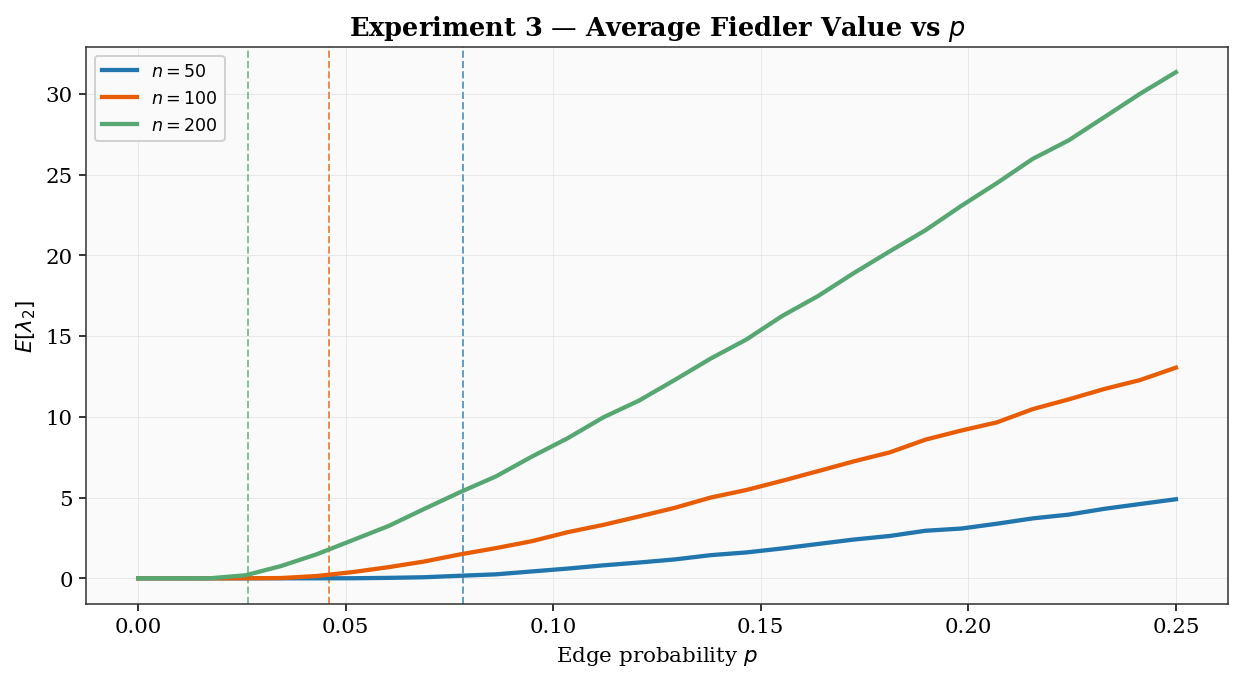

In [ ]:
n_values_f = [50, 100, 200]
trials_f = 300
p_grid_f = np.linspace(0, 0.25, 30)

fig, ax = plt.subplots(figsize=(9, 5))

for idx, n in enumerate(n_values_f):
    avg_lam2 = []
    for p in p_grid_f:
        vals = [erdos_renyi(n, p).fiedler_value() for _ in range(trials_f)]
        avg_lam2.append(sum(vals) / len(vals))

    p_star = math.log(n) / n
    c = PALETTE[idx]

    ax.plot(p_grid_f, avg_lam2, color=c, linewidth=2.2, label=f'$n={n}$', zorder=3)
    ax.axvline(p_star, color=c, linestyle='--', linewidth=1, alpha=0.7, zorder=1)

ax.set_xlabel('Edge probability $p$')
ax.set_ylabel('$E[\\lambda_2]$')
ax.set_title('Experiment 3 — Average Fiedler Value vs $p$', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

The nullity of $L$ equals the number of connected components, so $\lambda_2 = 0$ when disconnected and $\lambda_2 > 0$ when connected. The curves for different $n$ have different slopes after the threshold. For large $p$, the expected degree is $np \gg \ln n$, and random matrix theory predicts $\lambda_2 \approx np - 2\sqrt{np}$ — roughly linear in $p$ with a slope proportional to $n$.

---
## Experiment 4 — Minimum Degree Bound (Theorem 3.4)



We have $\lambda_2 \leq \delta(G)$ for any graph, where $\delta(G) = \min_v \deg(v)$.

We generate 1500 random graphs ($n=100$) at 30 different densities. For each graph we compute $\delta(G)$ and $\lambda_2$ and scatter-plot them. The line $\lambda_2 = \delta$ is the theoretical upper bound. Every point should lie on or below the red line.

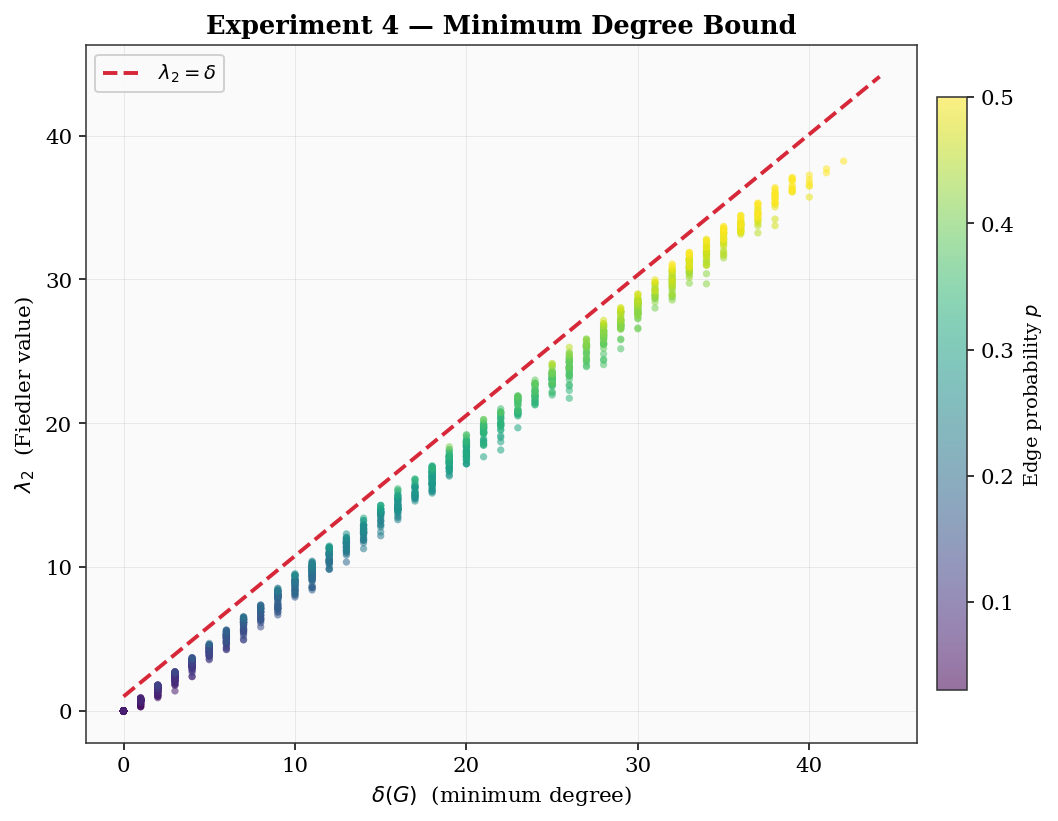

Violations (λ₂ > δ): 0 / 1500


In [ ]:
n = 100
deltas = []
lam2s = []
p_vals = []

p_sweep = np.linspace(0.03, 0.5, 30)
for p in p_sweep:
    for _ in range(50):
        G = erdos_renyi(n, p)
        delta = min(G.degree(v) for v in range(G.n))
        lam2 = G.fiedler_value()
        deltas.append(delta)
        lam2s.append(lam2)
        p_vals.append(p)

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(deltas, lam2s, c=p_vals, cmap='viridis', s=14, alpha=0.55,
                edgecolors='none', zorder=3)
cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Edge probability $p$', fontsize=10)

bound_max = max(max(deltas), max(lam2s) - 1) * 1.05
ax.plot([0, bound_max], [1, bound_max], color=PALETTE[3],
        linestyle='--', linewidth=2, zorder=4,
        label='$\\lambda_2 = \\delta$')

ax.set_xlabel('$\\delta(G)$  (minimum degree)')
ax.set_ylabel('$\\lambda_2$  (Fiedler value)')
ax.set_title('Experiment 4 — Minimum Degree Bound', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

violations = sum(1 for d, l in zip(deltas, lam2s) if l > d + 1e-9)
print(f'Violations (λ₂ > δ): {violations} / {len(lam2s)}')